# Meadowlark example

Available BMP files:
  - Astig3.bmp
  - mlo.bmp
  - Power3.bmp

Reading: Astig3.bmp
Image shape: (1024, 1024)
Image dtype: uint8
Image mode: L


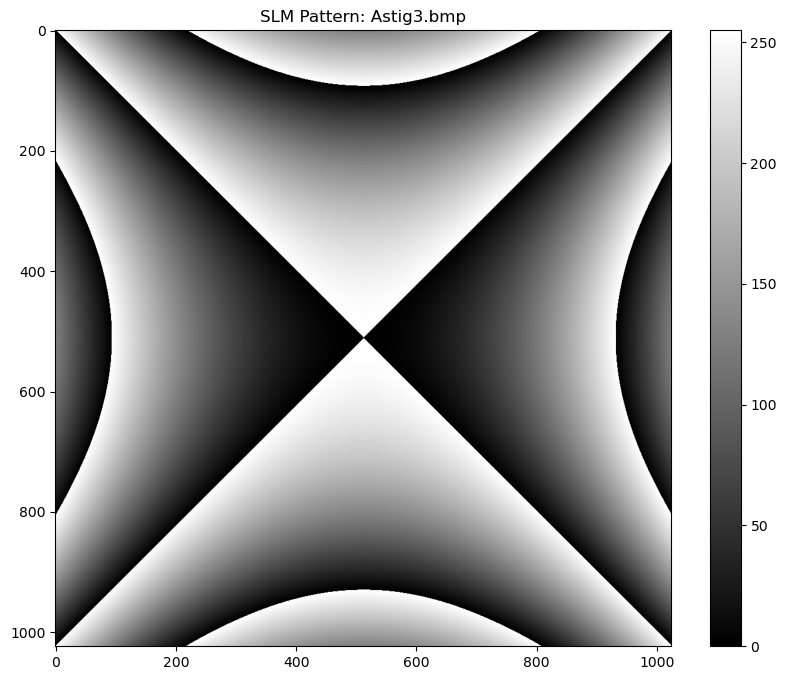


Image statistics:
  Min value: 0
  Max value: 255
  Mean value: 127.12
  Std deviation: 79.35


In [38]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Directory containing BMP files
bmp_dir = r"C:\Program Files\Meadowlark Optics\Blink OverDrive Plus\Image Files\1024"

# List all BMP files in the directory
bmp_files = [f for f in os.listdir(bmp_dir) if f.endswith('.bmp')]
print("Available BMP files:")
for f in bmp_files:
    print(f"  - {f}")

# Read the first BMP file (or specify which one you want)
if bmp_files:
    # You can change this to read a specific file: 'Astig3.bmp', 'mlo.bmp', or 'Power3.bmp'
    bmp_filename = bmp_files[0]  # Change index or filename as needed
    bmp_path = os.path.join(bmp_dir, bmp_filename)
    
    # Read the BMP file
    img = Image.open(bmp_path)
    img_array = np.array(img)
    
    print(f"\nReading: {bmp_filename}")
    print(f"Image shape: {img_array.shape}")
    print(f"Image dtype: {img_array.dtype}")
    print(f"Image mode: {img.mode}")
    
    # Display the image
    plt.figure(figsize=(10, 8))
    plt.imshow(img_array, cmap='gray' if len(img_array.shape) == 2 else None)
    plt.title(f"SLM Pattern: {bmp_filename}")
    plt.colorbar()
    plt.show()
    
    # Display image statistics
    print(f"\nImage statistics:")
    print(f"  Min value: {img_array.min()}")
    print(f"  Max value: {img_array.max()}")
    print(f"  Mean value: {img_array.mean():.2f}")
    print(f"  Std deviation: {img_array.std():.2f}")
else:
    print("No BMP files found in the directory")

# Onepunchman

Saved resized image as: C:\Users\PETANQUE-PC\Pictures\onepunchman_forFabien_resized.bmp
Reading: onepunchman_forFabien.jpg
Original image size: (894, 883)
Resized image shape: (1024, 1024)
Image dtype: uint8
Image mode: L


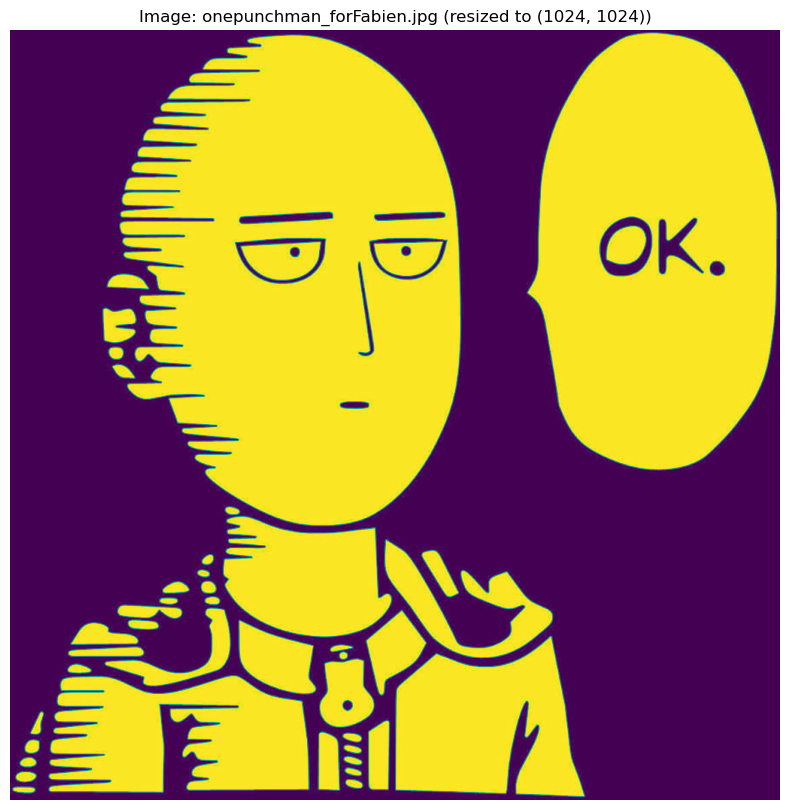


Image statistics:
  Min value: 0
  Max value: 255
  Mean value: 125.75
  Std deviation: 125.05


In [39]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Read the JPG file
jpg_path = r"C:\Users\PETANQUE-PC\Pictures\onepunchman_forFabien.jpg"

# Read the JPG file
img = Image.open(jpg_path)

# Resize to match the first image size (1024, 1024)
target_size = (1024, 1024)
img_resized = img.resize(target_size, Image.Resampling.LANCZOS)

# Convert to grayscale mode "L" to match the first BMP image
img_resized = img_resized.convert("L")

# Save as BMP file
bmp_output_path = r"C:\Users\PETANQUE-PC\Pictures\onepunchman_forFabien_resized.bmp"
img_resized.save(bmp_output_path, "BMP")
print(f"Saved resized image as: {bmp_output_path}")

img_array = np.array(img_resized)

print(f"Reading: {os.path.basename(jpg_path)}")
print(f"Original image size: {img.size}")
print(f"Resized image shape: {img_array.shape}")
print(f"Image dtype: {img_array.dtype}")
print(f"Image mode: {img_resized.mode}")

# Display the image
plt.figure(figsize=(12, 10))
plt.imshow(img_array)
plt.title(f"Image: {os.path.basename(jpg_path)} (resized to {target_size})")
plt.axis('off')
plt.show()

# Display image statistics
print(f"\nImage statistics:")
print(f"  Min value: {img_array.min()}")
print(f"  Max value: {img_array.max()}")
print(f"  Mean value: {img_array.mean():.2f}")
print(f"  Std deviation: {img_array.std():.2f}")
if len(img_array.shape) == 3:
    print(f"  Number of channels: {img_array.shape[2]}")

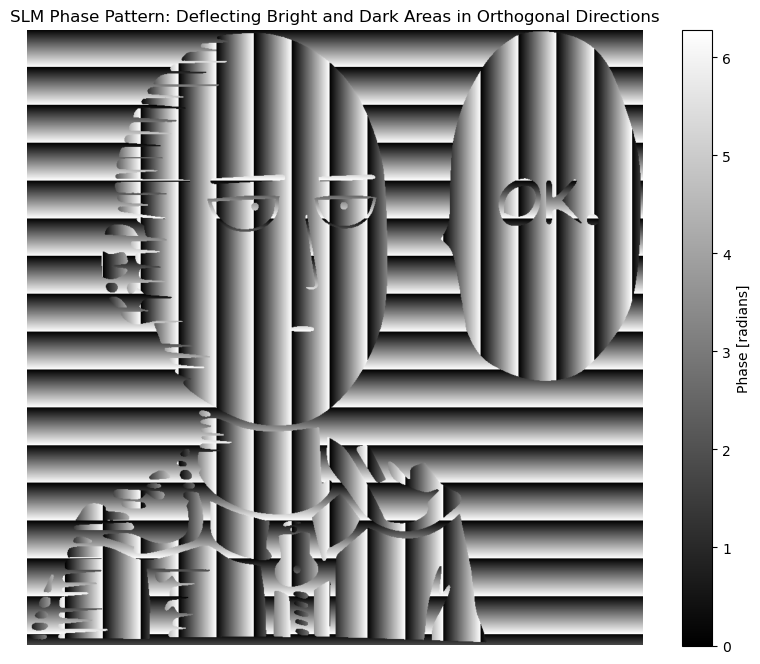

Saved BMP image as: SLM_patterns\secret_pattern.bmp


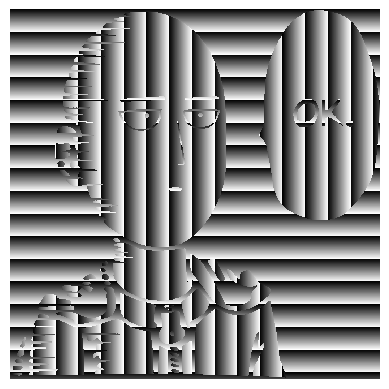

In [40]:

# NEW IDEA: Deflect light for dark areas in the image in one direction,
# and deflect light for bright areas in an orthogonal direction.

# Parameters for gratings (deflection slopes)
blaze_grating_slope_dark = 0.10     # Slope for "dark" areas (e.g., vertical deflection)
blaze_grating_slope_bright = 0.10   # Slope for "bright" areas (e.g., horizontal deflection)

# Define the threshold separating "dark" and "bright" pixels (range: 0-255)
threshold = 128

# Prepare SLM phase pattern
SLM_shape = img_array.shape
SLM_phase = np.zeros(SLM_shape)

# Coordinates
Y, X = np.indices(SLM_shape)

# Logical mask for bright pixels (above threshold)
bright_mask = img_array >= threshold
dark_mask = ~bright_mask

# Apply distinct gratings/phases for each region
# Bright: e.g. horizontal grating (deflection along x)
# Dark:   e.g. vertical grating (deflection along y)
SLM_phase[bright_mask] = (blaze_grating_slope_bright * X[bright_mask])   # e.g., horizontal deflection
SLM_phase[dark_mask]   = (blaze_grating_slope_dark * Y[dark_mask])       # e.g., vertical deflection

# Wrap phase to [0, 2pi]
SLM_phase_wrapped = np.mod(SLM_phase, 2 * np.pi)

plt.figure(figsize=(10, 8))
plt.imshow(SLM_phase_wrapped, cmap='gray', vmin=0, vmax=2 * np.pi)
plt.title("SLM Phase Pattern: Deflecting Bright and Dark Areas in Orthogonal Directions")
plt.colorbar(label="Phase [radians]")
plt.axis("off")
plt.show()

# Save or process SLM_phase_wrapped as needed for actual SLM usage
# Save SLM_phase_wrapped as a BMP image named "secret_pattern.bmp" for the SLM, using uint8 scaling
from PIL import Image
import os

# Define a save folder (adjust path as needed)
save_folder = r"SLM_patterns"

# Make sure the save folder exists
if not os.path.exists(save_folder):
    raise FileNotFoundError(f"Cannot find the folder: {save_folder}")

output_path = os.path.join(save_folder, "secret_pattern.bmp")
SLM_phase_uint8 = np.uint8(SLM_phase_wrapped / (2 * np.pi) * 255)
plt.imshow(SLM_phase_uint8, cmap="gray", interpolation="none")
plt.axis("off")

Image.fromarray(SLM_phase_uint8).save(output_path)
print(f"Saved BMP image as: {output_path}")
plt.show()




### Fourier transform

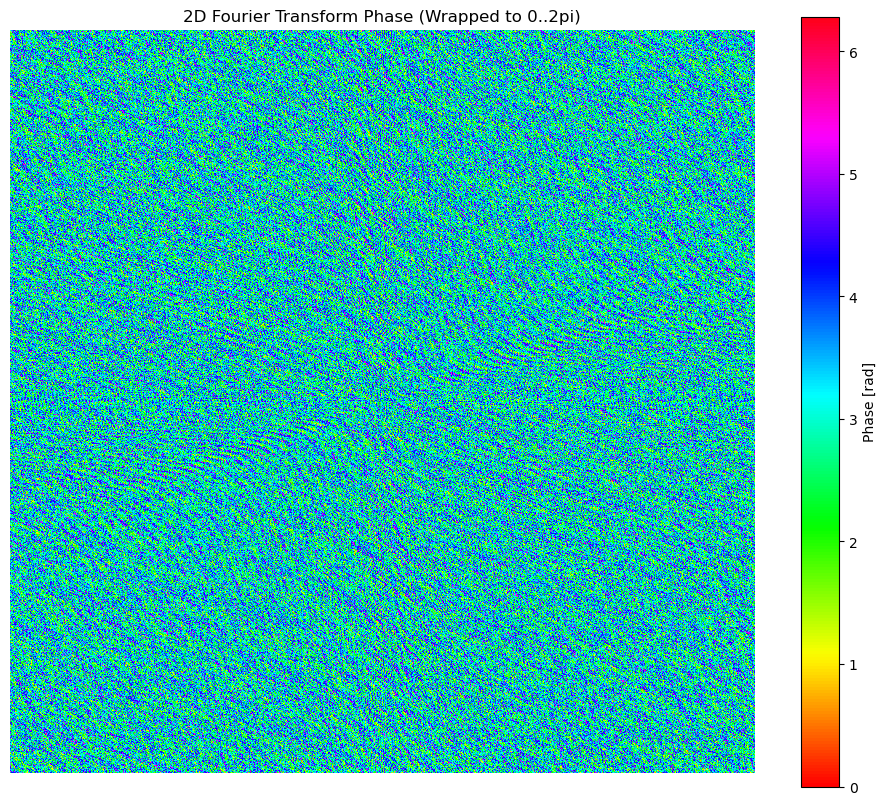

Saved Fourier phase BMP image as: SLM_patterns\fourier_phase_pattern.bmp


In [41]:

# Load the original JPG image file for the Fourier transform
jpg_path = r"C:\Users\PETANQUE-PC\Pictures\onepunchman_forFabien.jpg"
original_image = Image.open(jpg_path).convert('L')
original_image_np = np.array(original_image)

# Optionally, resize/crop/pad original_image_np to match expected shape, if necessary

# Resize or pad the image to 1024x1024 for SLM
target_size = (1024, 1024)
if original_image_np.shape != target_size:
    # We will resize the image to match the SLM pattern size; you can replace with zero-padding if that's preferable
    from skimage.transform import resize
    original_image_resized = resize(original_image_np, target_size, order=1, preserve_range=True).astype(np.uint8)
else:
    original_image_resized = original_image_np

# Compute the 2D Fourier transform of the (1024, 1024) image
F = np.fft.fft2(original_image_resized)
F_shifted = np.fft.fftshift(F)  # Shift zero freq to center

# Extract and wrap the phase to [0, 2pi)
phase_spectrum = np.angle(F_shifted)  # In range [-pi, pi]
phase_spectrum_wrapped = (phase_spectrum + 2 * np.pi) % (2 * np.pi)  # Now in [0, 2pi)

# Visualize the phase as a color image for display
plt.figure(figsize=(12, 10))
plt.imshow(phase_spectrum_wrapped, cmap='hsv', vmin=0, vmax=2*np.pi)
plt.title("2D Fourier Transform Phase (Wrapped to 0..2pi)")
plt.colorbar(label="Phase [rad]")
plt.axis("off")
plt.show()

# Map phase values (0 to 2pi) to 0..255 for SLM
phase_uint8 = np.uint8(phase_spectrum_wrapped / (2 * np.pi) * 255)

# Save phase pattern as a BMP for SLM
phase_bmp_path = os.path.join(save_folder, "fourier_phase_pattern.bmp")
phase_image = Image.fromarray(phase_uint8)
phase_image.save(phase_bmp_path)
print(f"Saved Fourier phase BMP image as: {phase_bmp_path}")



# Alignment

Saved BMP image as: SLM_patterns\SLM_pattern.bmp


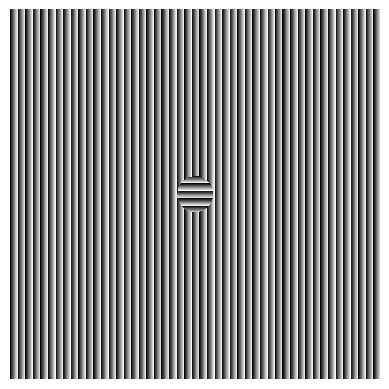

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

save_folder = r"SLM_patterns"

SLM_pattern = np.zeros((1024, 1024))
i0 = 512
j0 = 512
R = 50


blaze_grating_slope = 0.3

for i in range(1024):
    for j in range(1024):
        if ((i - i0)**2 + (j- j0)**2) > R**2:
            SLM_pattern[i, j] = 0.00 * i + blaze_grating_slope * j
        else:
            SLM_pattern[i, j] = blaze_grating_slope * i + 0.00 * j

SLM_pattern = SLM_pattern % (2 * np.pi)

# Make sure the save folder exists
if not os.path.exists(save_folder):
    raise FileNotFoundError(f"Cannot find the folder: {save_folder}")

output_path = os.path.join(save_folder, "SLM_pattern.bmp")
SLM_pattern_uint8 = np.uint8(SLM_pattern / (2 * np.pi) * 255)
plt.imshow(SLM_pattern_uint8, cmap="gray", interpolation="none")
plt.axis("off")

Image.fromarray(SLM_pattern_uint8).save(output_path)
print(f"Saved BMP image as: {output_path}")



plt.show()

# LUT calibration

In [43]:
for value_high in range(0, 255, 5):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    import os

    save_folder = r"SLM_patterns"

    SLM_pattern = np.zeros((1024, 1024))
    period_pixel = 8
    # value_high = 20
    value_low = 0

    for i in range(1024):
        for j in range(1024):
            if (i//period_pixel) % 2 == 0:
                SLM_pattern[i, j] = value_high
            else:
                SLM_pattern[i, j] = value_low

    # Make sure the save folder exists
    if not os.path.exists(save_folder):
        raise FileNotFoundError(f"Cannot find the folder: {save_folder}")

    output_path = os.path.join(save_folder, "LUT_pattern_{:03d}.bmp".format(value_high))
    SLM_pattern_uint8 = np.uint8(SLM_pattern)
    # plt.imshow(SLM_pattern_uint8, cmap="gray", interpolation="none", vmax=255, vmin=0)
    # plt.axis("off")

    # Image.fromarray(SLM_pattern_uint8).save(output_path)
    # print(f"Saved BMP image as: {output_path}")



    plt.show()

# Hologram

## Weighted Gerchberg-Saxton (WGS)

Optimize the phase and weight of each grating. Optionally correct for SLM diffraction efficiency vs trap displacement.

In [46]:
# Dependencies for WGS: GPU module and SLM parameters
import numpy as np
import os
import sys

# Ensure the folder containing SLM_gpu_module_v2_0.py is on the path
_candidates = [
    os.getcwd(),
    os.path.join(os.getcwd(), 'SLM software'),
    os.path.dirname(os.path.abspath(os.getcwd())),
]
for _d in _candidates:
    if os.path.isfile(os.path.join(_d, 'SLM_gpu_module_v2_0.py')):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break
else:
    raise FileNotFoundError(
        "SLM_gpu_module_v2_0.py not found. Run this notebook from the project root or from the 'SLM software' folder."
    )

from SLM_gpu_module_v2_0 import slm_to_trap_amp, trap_phase_to_slm

# Minimal SLM parameter namespace (match your SLM resolution)
class Param:
    ImgResX = 792
    ImgResY = 600

param = Param()
SLM_DIFFRACTION_EFFICIENCY_HWHM = 90e-6  # meters
SLM_shape = (param.ImgResY, param.ImgResX)

ImportError: cannot import name 'TypeIs' from 'typing_extensions' (c:\Users\PETANQUE-PC\anaconda3\Lib\site-packages\typing_extensions.py)

In [ ]:
# Trap state and computeHologram (required by WGS)
# Build trap arrays: traps_k (N_traps x 3), traps_pos (N_traps x 4), theta_traps, weight_traps, pupil_traps.
# You can load from a .pkl trap file or define synthetic traps.

# Example: synthetic 4 traps in a square (positions in µm: x, y, z). Adjust to your setup.
# To use real param (lamb, M, f, pslm) for k-vectors, import your parameters module and set position_to_step_per_pixel.
position_to_step_per_pixel = 2 * np.pi / 850e-9 * (1.0 / 0.2) * 10e-6   # example: lambda, M/f, pslm
position_to_step_per_pixel_for_z = np.pi / 850e-9 * (1.0 / 0.2)**2 * (10e-6)**2

traps_pos_um = np.array([
    [0, -20, -20, 0],
    [1,  20, -20, 0],
    [2, -20,  20, 0],
    [3,  20,  20, 0],
])  # id, x_µm, y_µm, z_µm
traps_pos = np.zeros((len(traps_pos_um), 4))
traps_pos[:, 0] = traps_pos_um[:, 0]
traps_pos[:, 1:4] = traps_pos_um[:, 1:4] * 1e-6   # convert to meters

traps_k = np.copy(traps_pos[:, 1:4])
traps_k[:, 0:2] *= position_to_step_per_pixel
traps_k[:, 2]   *= position_to_step_per_pixel_for_z

N_traps = len(traps_k)
theta_traps = np.random.rand(N_traps) * 2 * np.pi
weight_traps = np.ones(N_traps)
pupil_traps = {
    'pupil_longaxis': np.ones(N_traps) * 300,
    'pupil_shortaxis': np.ones(N_traps) * 300,
    'pupil_angle': np.zeros(N_traps),
}
dx, dy = 0.0, 0.0   # global tilt (µm)

def computeHologram():
    """Phase pattern from current theta_traps, weight_traps, traps_k, pupil_traps."""
    return trap_phase_to_slm(
        traps_k,
        theta_traps,
        weight_traps,
        pupil_traps,
        shape=SLM_shape,
    )

In [ ]:
def WGS(correct_diffraction_efficiency=False, GSW_maxit=10):
    """
    Weighted Gerchberg-Saxton. Optimize the phase and weight of each grating.
    Uses global: traps_k, traps_pos, theta_traps, weight_traps, dx, dy, N_traps, param, computeHologram.
    """
    print('Starting weighted Gerchberg-Saxton calculation')

    if correct_diffraction_efficiency:
        traps_displacements = (
            (traps_pos[:, 1] + dx * 1e-6)**2 + (traps_pos[:, 2] + dy * 1e-6)**2
        )**0.5
        SLM_diffraction_efficiency = 1.0 - 0.5 * traps_displacements / SLM_DIFFRACTION_EFFICIENCY_HWHM
        target_intensities = 1.0 / SLM_diffraction_efficiency
        target_amplitudes = target_intensities**0.5
        target_amplitudes_norm = target_amplitudes / np.mean(target_amplitudes)
    else:
        target_intensities = np.ones(N_traps)
        target_amplitudes_norm = np.ones(N_traps)

    phi = computeHologram()
    traps_amplitude = 1.0 / param.ImgResY / param.ImgResX * slm_to_trap_amp(phi, traps_k)
    trap_intensities = np.real(traps_amplitude * np.conj(traps_amplitude))
    deviation_from_target = trap_intensities / target_intensities
    rel_dev = deviation_from_target**0.5 / np.mean(deviation_from_target**0.5)
    efficiency = np.sum(trap_intensities)
    uniformity = np.std(deviation_from_target) / np.mean(deviation_from_target)

    print('Initial calculation:')
    print('Efficiency std = %.1f' % (efficiency * 100))
    print('Intensity std = %.1f' % (uniformity * 100))

    for k in range(GSW_maxit):
        theta_traps[:] = np.angle(traps_amplitude)
        weight_traps[:] *= 1.0 / rel_dev

        phi = computeHologram()
        traps_amplitude = 1.0 / param.ImgResY / param.ImgResX * slm_to_trap_amp(phi, traps_k)
        trap_intensities = np.real(traps_amplitude * np.conj(traps_amplitude))
        deviation_from_target = trap_intensities / target_intensities
        rel_dev = deviation_from_target**0.5 / np.mean(deviation_from_target**0.5)
        efficiency = np.sum(trap_intensities)
        uniformity = np.std(deviation_from_target) / np.mean(deviation_from_target)
        print('Efficiency std = %.1f' % (efficiency * 100))
        print('Intensity std = %.1f' % (uniformity * 100))

    return phi

In [ ]:
# Run WGS (without diffraction-efficiency correction, 10 iterations)
phi_wgs = WGS(correct_diffraction_efficiency=False, GSW_maxit=10)

# Optional: plot the phase pattern
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.imshow(phi_wgs, cmap='twilight')
plt.colorbar(label='Phase (rad)')
plt.title('WGS phase pattern')
plt.show()

Starting weighted Gerchberg-Saxton calculation


NameError: name 'trap_phase_to_slm' is not defined